In [43]:
import pandas as pd

In [ ]:
#reading scaled dataframe
df = pd.read_csv('../data/cleaned_music_data.csv')

In [ ]:
#making a temporary dataframe without artists and track_names for clustering
df_temp = df.drop(columns=['artists', 'track_name'])

In [ ]:
#using KMeans to cluster data with
from sklearn.cluster import KMeans

In [ ]:
#using the elbow method to find number of clusters
inertia_scores = []
for k in range(1, 11):

    #defining the kmeans model and fitting data
    kmeans_model = KMeans( n_clusters = k, random_state = 42)
    kmeans_model.fit(df_temp)

    #adding the intertia score to the list so that we can see which ones are better later
    inertia_scores.append(kmeans_model.inertia_)
    print(f'K:{k}, Score: {kmeans_model.inertia_}')

K: 1, Inertia Score: 911991.9999999991
K: 2, Inertia Score: 692686.4212317109
K: 3, Inertia Score: 603301.5410921169
K: 4, Inertia Score: 538576.2642044968
K: 5, Inertia Score: 486401.95356148866
K: 6, Inertia Score: 425418.9437619135
K: 7, Inertia Score: 396707.115642732
K: 8, Inertia Score: 373174.3257127338
K: 9, Inertia Score: 359857.02234466287
K: 10, Inertia Score: 341407.142112289


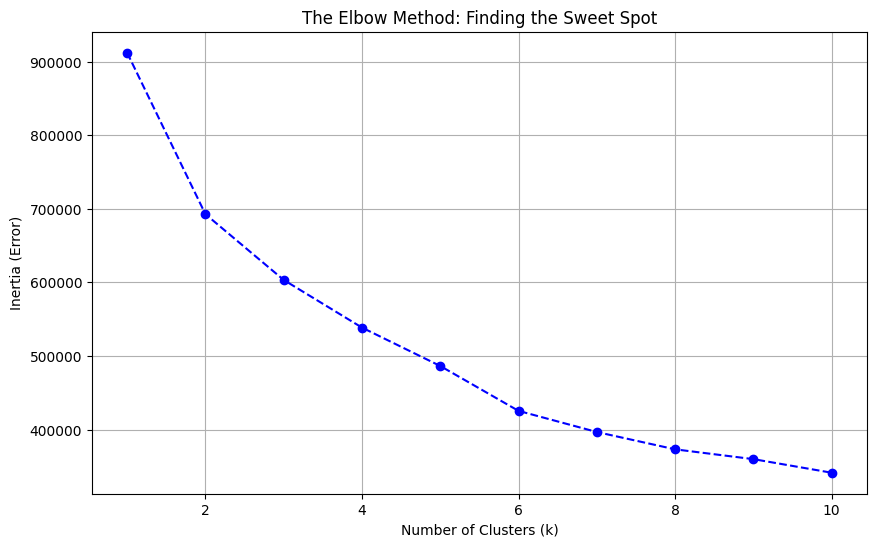

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Plotting K values against the Inertia
plt.plot(range(1, 11), inertia_scores, color='r')

#formatting
plt.title('KMeans Elbow Method')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

In [ ]:
#picking a k of 6 
model = KMeans(n_clusters = 6, n_init = 10,random_state = 42)

#labeling rows 0-5 based on model
clusters_labels = model.fit_predict(df_temp)
df_temp['cluster_label'] = clusters_labels

In [ ]:
#visualizing the cluster additions
print(df_temp['cluster_label'].value_counts())
df_temp.head()

cluster_label
4    37514
1    28462
2    23925
3    12057
5     7516
0     4525
Name: count, dtype: int64


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,tempo,valence,cluster_label
0,0.629239,-0.717147,0.300825,0.551843,-0.850193,-0.504111,-1.141854,0.929315,4
1,-0.845908,-1.889974,-1.784739,-0.078995,1.831744,-0.504097,-1.489708,-0.798681,2
2,-0.742187,-1.122667,-0.293289,-0.273827,-0.315489,-0.504115,-1.528303,-1.365679,2
3,-1.733301,-2.312987,-2.039246,-0.457309,1.774605,-0.503886,1.987857,-1.276965,2
4,0.295026,-0.788709,-0.282751,-0.303146,0.463409,-0.504115,-0.073343,-1.184394,2


In [ ]:
#adding the track_name and artists back into the dataframe
df_clustered = df_temp.join(df[['track_name','artists']])

In [ ]:
#saving the clustered dataframe into a csv file
df_clustered.to_csv('../data/clustered_data.csv', index=False)

In [ ]:
#seeing the final dataset one final time
df_clustered.head(50)

NameError: name 'df_clustered' is not defined